## PART A: PREPROCESSING

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.titleweight": "bold"})
BLUE, ORANGE, GREY = "#1f6feb", "#fb8500", "#9aa0a6"
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"; IMG = ROOT / "images" / "partB"; IMG.mkdir(parents=True, exist_ok=True)
(ROOT / "models").mkdir(exist_ok=True)

## 1. Load and protect the raw data

In [3]:
energy_raw = pd.read_csv(DATA / "energy_dataset.csv")
weather_raw = pd.read_csv(DATA / "weather_features.csv")
energy, weather = energy_raw.copy(), weather_raw.copy()
print("energy", energy.shape, "| weather", weather.shape)

energy (35064, 29) | weather (178396, 17)


## 2. Timeline integrity

In [4]:
energy["time"]  = pd.to_datetime(energy["time"], utc=True, errors="coerce")
weather["time"] = pd.to_datetime(weather["dt_iso"], utc=True, errors="coerce")
energy = energy.sort_values("time").reset_index(drop=True)
full = pd.date_range(energy["time"].min(), energy["time"].max(), freq="h", tz="UTC")
print("duplicate hours:", int(energy["time"].duplicated().sum()),
      "| missing hours:", len(full.difference(pd.DatetimeIndex(energy["time"]))))

duplicate hours: 0 | missing hours: 0


0 duplicates and 0 missing hours, so the index is regular and positional lags (shift 24, 168) are safe

## 3. Target, reference, horizon

In [5]:
TARGET, REFERENCE, HORIZON = "total load actual", "total load forecast", 24
p = energy[[TARGET, REFERENCE]].dropna()
mape = ((p[REFERENCE] - p[TARGET]).abs() / p[TARGET]).mean() * 100
print(f"reference forecast MAPE = {mape:.2f}%  |  target missing values: {int(energy[TARGET].isna().sum())}")

reference forecast MAPE = 1.10%  |  target missing values: 36


The reference sits at about 1.1% MAPE, very strong. We compare against it, we never feed it in (it already forecast the target)

## 4. Drop dead columns

In [6]:
empty_cols = [c for c in energy.columns if energy[c].isna().all()]
num = energy.select_dtypes("number")
zero_cols = [c for c in num.columns if c not in empty_cols and (num[c].dropna()== 0).all()]
energy = energy.drop(columns=empty_cols + zero_cols)
print("dropped", len(empty_cols + zero_cols), "->", energy.shape[1], "cols", empty_cols + zero_cols)

dropped 8 -> 21 cols ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead', 'generation fossil coal-derived gas', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation marine', 'generation wind offshore']


## 5. Weather to one row per hour, then merge

In [7]:
weather["city_name"] = weather["city_name"].str.strip()
weather = weather.drop_duplicates(subset=["time", "city_name"])
wnum = [c for c in weather.select_dtypes("number").columns if c != "weather_id"]
weather_agg = weather.groupby("time")[wnum].mean().reset_index()
for c in ["temp", "temp_min", "temp_max"]: weather_agg[c] -= 273.15
df = energy.merge(weather_agg, on="time", how="left")
print("df", df.shape), "| hours with no weather match:", int(df[wnum].isna().all(axis=1).sum())

df (35064, 32)


(None, '| hours with no weather match:', 0)

## 6. Distributions and box plots

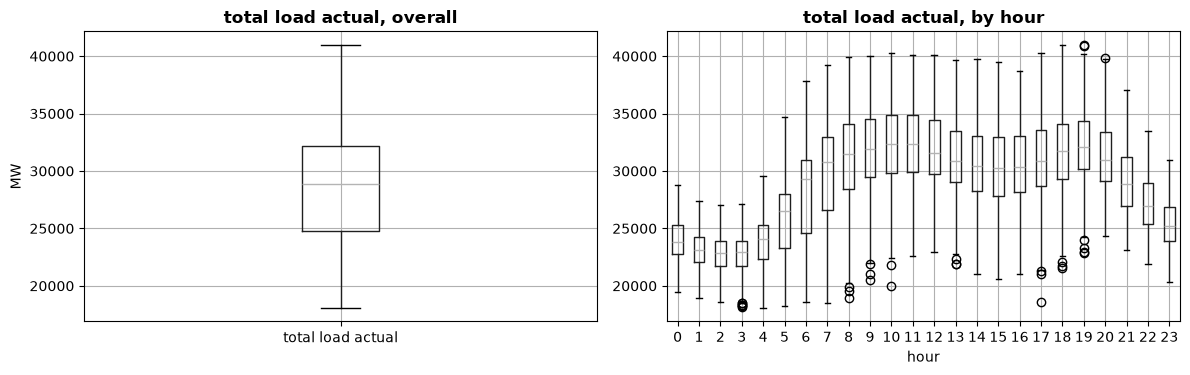

In [8]:
df["hour"] = df["time"].dt.hour
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.boxplot(column=TARGET, ax=ax[0]); ax[0].set_title("total load actual, overall"); ax[0].set_ylabel("MW")
df.boxplot(column=TARGET, by="hour", ax=ax[1]); ax[1].set_title("total load actual, by hour"); ax[1].set_xlabel("hour")
plt.suptitle(""); fig.tight_layout(); fig.savefig(IMG / "box_target.png", dpi=130); plt.show()

The high target values are normal peak load values

## 7. Missing values: where, how much, isolated or clustered

total load actual                              0.10
generation hydro pumped storage consumption    0.05
generation biomass                             0.05
generation hydro run-of-river and poundage     0.05
generation fossil oil                          0.05
generation waste                               0.05
generation fossil brown coal/lignite           0.05
generation fossil hard coal                    0.05
generation fossil gas                          0.05
generation hydro water reservoir               0.05
generation other                               0.05
generation solar                               0.05
generation other renewable                     0.05
generation wind onshore                        0.05
generation nuclear                             0.05


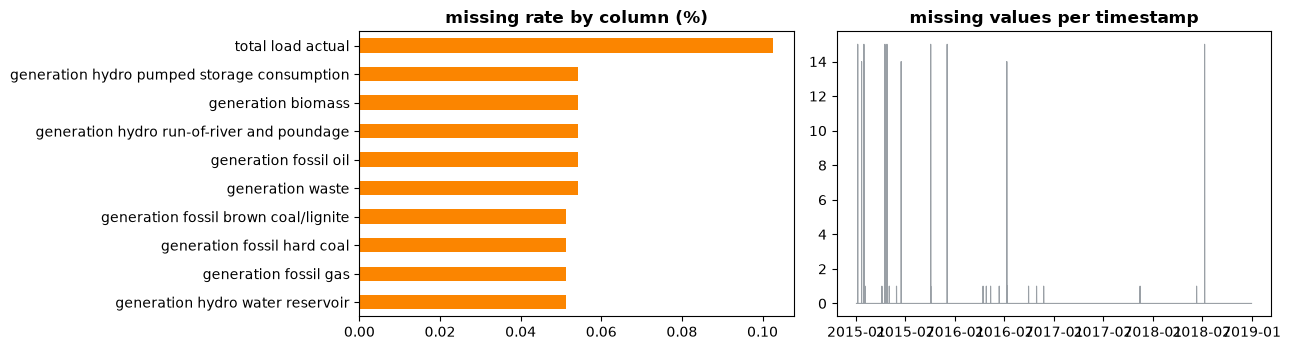

In [9]:
rate = df.isna().mean() * 100; rate = rate[rate > 0].sort_values(ascending=False)
print(rate.round(2).to_string())
miss_t = df.set_index("time").isna().sum(axis=1)
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
rate.head(10).iloc[::-1].plot.barh(ax=ax[0], color=ORANGE); ax[0].set_title("missing rate by column (%)")
ax[1].plot(miss_t.index, miss_t.values, color=GREY, lw=0.8); ax[1].set_title("missing values per timestamp")
fig.tight_layout(); fig.savefig(IMG / "missing.png", dpi=130); plt.show()

1. Gap characteristics:
    - Overall missing rate is extremely low: All columns have less than $0.11\%$ missing values (e.g., total load actual is only $0.10\%$ missing).
    - Pattern: Looking at the "missing values per timestamp" plot on the right, the gaps appear as isolated spikes (thin vertical lines occurring at specific hours/short intervals) rather than long, continuous solid blocks of missing data.
2. Implication for filling/imputation:
    - Because the missing gaps are short and isolated, time-based linear interpolation (interpolate(method='time')) or forward fill (ffill()) is optimal.
    - It allows us to accurately estimate missing values using adjacent hourly observations without distorting the underlying daily cycle or signal continuity.

## 8. Choosing an imputation method
 Each method fits a situation.

| Method | Good when | Watch out |
|---|---|---|
| median or mean | numeric feature, order does not matter | the mean is pulled by outliers |
| forward fill (ffill) | short gap in a continuous signal | repeats the last past value, fine |
| time interpolation | short isolated gaps, smooth signal | uses neighbours, a mild assumption |
| back fill (bfill) | never in forecasting | uses the future, forbidden |
| drop the column | the column is almost all empty | loses signal |
| flag and exclude | the target, which is a label | shrinks the labelled set |


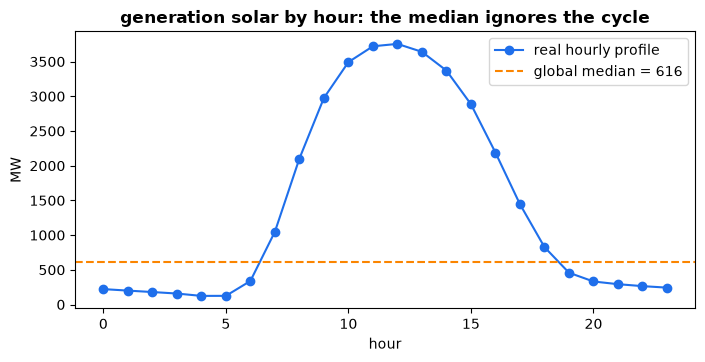

In [10]:
prof = df.groupby("hour")["generation solar"].mean()
gmed = df["generation solar"].median()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(prof.index, prof.values, marker="o", color=BLUE, label="real hourly profile")
ax.axhline(gmed, color=ORANGE, ls="--", label=f"global median = {gmed:.0f}")
ax.set_title("generation solar by hour: the median ignores the cycle")
ax.set_xlabel("hour"); ax.set_ylabel("MW"); ax.legend()
fig.savefig(IMG / "impute_choice.png", dpi=130); plt.show()

Generation features (isolated gaps, strong daily cycle):
- method = time interpolation (or time-based linear interpolation)
- why = it preserves the diurnal cycle (daily pattern) across neighboring hours, whereas a global median completely ignores the daily profile (e.g., predicting 616 MW during midnight when solar is zero).

Production pipeline (scores one row at a time):
- method = forward fill (ffill) (or pre-computed training medians)
- why = a live production API processes streaming data one incoming row at a time in real time, so it cannot look into future rows to perform time interpolation.

## 9. The target is special

In [11]:
df["target_missing"] = df[TARGET].isna()
df["target_filled"] = df[TARGET].interpolate(method="linear")   # TODO: keep the series regular without inventing scored values (hint: interpolate over time)
print("target gaps:", int(df["target_missing"].sum()))

target gaps: 36


## 10. Treat outliers

pressure: worst single city  1,008,371 hPa  ->  hourly mean still   202,469   (real near 1013, the error PROPAGATED through the mean)
wind    : worst single city        133 m/s  ->  hourly mean only       29.8   (storm near 30, the error was HIDDEN by the mean)


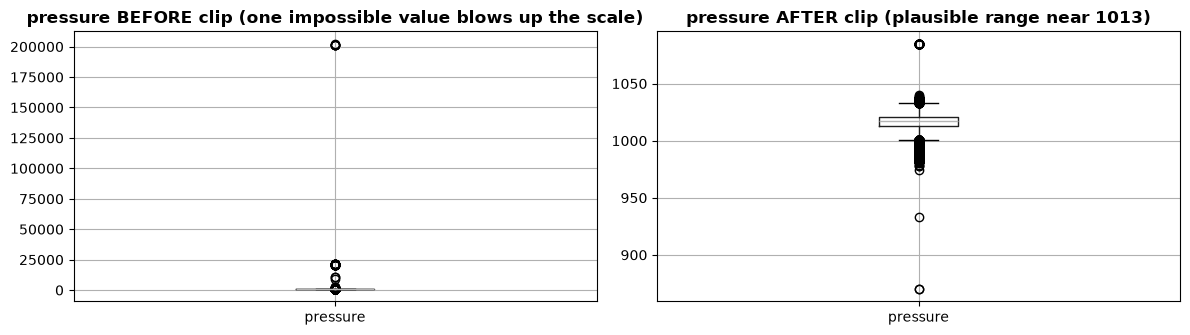

In [12]:
pc, ph = weather["pressure"].max(), df["pressure"].max()
wc, wh = weather["wind_speed"].max(), df["wind_speed"].max()
print(f"pressure: worst single city {pc:>10,.0f} hPa  ->  hourly mean still {ph:>9,.0f}   (real near 1013, the error PROPAGATED through the mean)")
print(f"wind    : worst single city {wc:>10.0f} m/s  ->  hourly mean only  {wh:>9.1f}   (storm near 30, the error was HIDDEN by the mean)")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
df.boxplot(column="pressure", ax=ax[0]); ax[0].set_title("pressure BEFORE clip (one impossible value blows up the scale)")
df["pressure"]   = df["pressure"].clip(870, 1085)
df["wind_speed"] = df["wind_speed"].clip(0, 40)
df.boxplot(column="pressure", ax=ax[1]); ax[1].set_title("pressure AFTER clip (plausible range near 1013)")
plt.suptitle(""); fig.tight_layout(); fig.savefig(IMG / "outliers.png", dpi=130); plt.show()

The pressure error survived the average, the wind error was hidden by it. So check at the per-city level, and clip with fixed physical bounds. Clipping is a sepearte step from imputation.

## 11. Split by time, never random

In [13]:
year = df["time"].dt.year
train_df, val_df, test_df = df[year <= 2016].copy(), df[year == 2017].copy(), df[year == 2018].copy()
for n, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{n:5s} {d.shape[0]:6d}   {d['time'].min().date()} -> {d['time'].max().date()}")

train  17545   2014-12-31 -> 2016-12-31
val     8760   2017-01-01 -> 2017-12-31
test    8759   2018-01-01 -> 2018-12-31


1. The three sizes:
- Train size: $17,545$ rows (covering 2014-12-31 to 2016-12-31, approx. 2 full years)
- Validation (val) size: $8,760$ rows (covering all 365 days of 2017, $24 \times 365 = 8760$)
- Test size: $8,759$ rows (covering all of 2018)

2. Why the test year must stay untouched:
- Prevents Data Leakage: Fitting scalers, imputers, or tuning hyper-parameters using the test set would allow the model to "peek" into future statistics, leading to overly optimistic metric scores.
- Simulates Real-World Deployment: In production, a forecasting model must predict future demand using only historical data. Keeping 2018 untouched guarantees an unbiased evaluation of how well the trained model generalizes to completely unseen future years.

## 12. Choosing a scaler
Scaling puts features on a comparable footing. Not every model needs it.

| Scaler | What it does | Good when |
|---|---|---|
| StandardScaler | mean 0, std 1 | linear / Ridge / neural nets, the usual default |
| MinMaxScaler | rescales to [0, 1] | bounded inputs, but one outlier squashes the rest |
| RobustScaler | centers on median, scales by the IQR | features still skewed or with outliers |
| none | leave as is | tree models (RF, GBM, XGBoost) do not need scaling |

Linear and gradient based models need scaling; tree based models do not, and scaling does not hurt them.

In [14]:
print(df[[TARGET, "temp", "price actual"]].describe().loc[["min", "max"]].round(1).to_string())
print("\nThe features live on very different scales (load in tens of thousands, temp in tens), so a linear model needs scaling.")

     total load actual  temp  price actual
min            18041.0  -1.2           9.3
max            41015.0  36.1         116.8

The features live on very different scales (load in tens of thousands, temp in tens), so a linear model needs scaling.


For the Ridge baseline, StandardScalar is the safe default. Tree models (Random Forest, Gradient Boosting) do not need scaling, but it does no harm, so a single StandardScalar pipeline can serve both.If features stayed skewed after clipping, Robust would be worth trying because it is not pulled by extreme values.

## 13. Fit transforms on train only

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
feat = [c for c in df.select_dtypes("number").columns if c not in {TARGET, REFERENCE, "target_filled"}]
imp, sc = SimpleImputer(strategy="median"), StandardScaler()
X_train = sc.fit_transform(imp.fit_transform(train_df[feat]))
X_val   = sc.transform(imp.transform(val_df[feat]))
X_test  = sc.transform(imp.transform(test_df[feat]))
print("solar median  train:", round(train_df['generation solar'].median(), 1),
      "| all-data:", round(df['generation solar'].median(), 1), " <- fitting on all would leak val and test")

solar median  train: 629.0 | all-data: 616.0  <- fitting on all would leak val and test


The train median and the all-data median differ. The all-data one is contaminated by 2017 and 2018. which the model is not supposed to know yet

## 14. Wrap it in a pipeline and save it

In [17]:
from sklearn.pipeline import Pipeline
import joblib
preprocess = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
preprocess.fit(train_df[feat])
joblib.dump({"pipeline": preprocess, "features": feat}, ROOT / "models" / "preprocess.joblib")
print("pipeline:", [n for n, _ in preprocess.steps], "| saved to models/preprocess.joblib")

pipeline: ['imputer', 'scaler'] | saved to models/preprocess.joblib


## 15. Leakage and availability audit

| Column or family | Available at prediction time? | Use |
|---|-------------------------------|---|
| `total load actual` (target) | No                            |Target variable ($y$). Can only be used as past lagged features ($\ge 24\text{h}$).|
| `total load forecast` | Yes                           |Evaluation baseline / reference benchmark.|
| `generation *` (actual) | No                            |Off-limits for target hour; can only be used if lagged by $\ge 24\text{h}$. |
| `forecast * day ahead` | Yes                           |Direct predictive input features.|
| `price day ahead` | Yes                           |Direct predictive input feature.|
| `price actual` | No                            |Off-limits for target hour; must be excluded or lagged by $\ge 24\text{h}$. |
| weather (observed) | No                            |Proxy for day-ahead weather forecast at the target hour.|
| calendar (hour, dow, month) | Yes                           |Direct calendar and cyclic features (sin/cos)|

Safe inputs: calendar,day-ahead forecasts, and lagged past values. Off limits as same-hour inputs: actual generation, price actual, and the reference forecast.

## PART B: Feature Engineering and Baselines

In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.titleweight": "bold"})
BLUE, ORANGE, GREY = "#1f6feb", "#fb8500", "#9aa0a6"
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"; PROC = DATA / "processed"; PROC.mkdir(parents=True, exist_ok=True)
IMG = ROOT / "images"; (IMG / "partC").mkdir(parents=True, exist_ok=True); (IMG / "concepts").mkdir(parents=True, exist_ok=True)

## 1. Rebuild the protocol (condensed)

In [19]:
energy = pd.read_csv(DATA / "energy_dataset.csv")
energy["time"] = pd.to_datetime(energy["time"], utc=True)
energy = energy.sort_values("time").reset_index(drop=True)

weather = pd.read_csv(DATA / "weather_features.csv")
weather["time"] = pd.to_datetime(weather["dt_iso"], utc=True)
weather["city_name"] = weather["city_name"].str.strip()
weather = weather.drop_duplicates(subset=["time", "city_name"])
wnum = [c for c in weather.select_dtypes("number").columns if c != "weather_id"]
wagg = weather.groupby("time")[wnum].mean().reset_index()
for c in ["temp", "temp_min", "temp_max"]: wagg[c] -= 273.15

df = energy.merge(wagg, on="time", how="left")
df["pressure"] = df["pressure"].clip(870, 1085)
df["wind_speed"] = df["wind_speed"].clip(0, 40)

TARGET, REFERENCE = "total load actual", "total load forecast"
df["target_missing"] = df[TARGET].isna()
df["target_filled"]  = df.set_index("time")[TARGET].interpolate("time").values
print("df", df.shape, "| target gaps flagged:", int(df["target_missing"].sum()))

df (35064, 42) | target gaps flagged: 36


## 2. The day-ahead setup
At time t, we predict demand at **t + 24 hours**, using only information available at time t.

Consequence for the feature table: for a target hour T, every feature must be **at least 24 hours old**. So the most recent demand lag we may use is `lag_24` (the same hour yesterday), never `lag_1`. This is the leakage audit of Part B turned into a modeling rule.

A full 24-output forecaster (t+1 ... t+24) is the project extension; today one clean horizon teaches the correct discipline.

## 3. Calendar features

In [20]:
df["hour"] = df["time"].dt.hour
df["day_of_week"] = df["time"].dt.dayofweek
df["month"] = df["time"].dt.month
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)
df[["time", "hour", "day_of_week", "month", "is_weekend"]].head(3)

,time,hour,day_of_week,month,is_weekend
0,2014-12-31 23:00:00+00:00,23,2,12,0
1,2015-01-01 00:00:00+00:00,0,3,1,0
2,2015-01-01 01:00:00+00:00,1,3,1,0


## 4. Cyclic encoding
Hour 23 and hour 0 are one hour apart, but as raw numbers they look 23 apart

In [21]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df["day_of_week"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

## 5. Lag features

In [22]:
for lag in (24, 48, 168):
    df[f"load_lag_{lag}"] = df["target_filled"].shift(lag)   # TODO: shift target_filled by lag hours
df[["time", "target_filled", "load_lag_24", "load_lag_168"]].iloc[170:173]

,time,target_filled,load_lag_24,load_lag_168
170,2015-01-08 01:00:00+00:00,23889.0,27026.0,22734.0
171,2015-01-08 02:00:00+00:00,23046.0,26248.0,21286.0
172,2015-01-08 03:00:00+00:00,22587.0,25838.0,20264.0


## 6. Rolling features (past only)

In [26]:
df["load_roll_mean_24"]  = df["target_filled"].shift(24).rolling(24).mean()
df["load_roll_std_24"]   = df["target_filled"].shift(24).rolling(24).std()
df["load_roll_mean_168"] = df["target_filled"].shift(24).rolling(168).mean()
print("rolling windows end 24 h before the target hour: safe by construction")

rolling windows end 24 h before the target hour: safe by construction


## 7. Weather as a forecast proxy

In [23]:
WEATHER_FEATURES = ["temp", "humidity", "wind_speed"]
print("Assumption (documented): observed weather at the target hour stands in for a day-ahead weather forecast.")
df[WEATHER_FEATURES].describe().loc[["min", "mean", "max"]].round(1)

Assumption (documented): observed weather at the target hour stands in for a day-ahead weather forecast.


,temp,humidity,wind_speed
min,-1.2,22.6,0.0
mean,16.6,68.0,2.5
max,36.1,100.0,29.8


## 8. Assemble X and y, split by time

In [27]:
FEATURES = (["hour", "day_of_week", "month", "is_weekend",
             "hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos",
             "load_lag_24", "load_lag_48", "load_lag_168",
             "load_roll_mean_24", "load_roll_std_24", "load_roll_mean_168"]
            + WEATHER_FEATURES)

data = df[~df["target_missing"]].dropna(subset=FEATURES).copy()
year = data["time"].dt.year
train, val, test = data[year <= 2016], data[year == 2017], data[year == 2018]
for n, d in [("train", train), ("val", val), ("test", test)]:
    print(f"{n:5s} {d.shape[0]:6d}   {d['time'].min().date()} -> {d['time'].max().date()}")

train  17328   2015-01-08 -> 2016-12-31
val     8758   2017-01-01 -> 2017-12-31
test    8757   2018-01-01 -> 2018-12-31


The three metrics we use
Every forecast, baseline or model, is scored the same way. MAE, the mean absolute error, is the average error in megawatts and the easiest to read. RMSE squares the errors before averaging, so it punishes the large misses more. MAPE is the error as a percentage, which lets us compare with the provided forecast. MAE is our primary metric.

## 9. Baselines
A baseline tells us whether machine learning adds value.

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAPE_%": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)}

ref = test.dropna(subset=[REFERENCE])
baselines = pd.DataFrame([
    {"model": "Naive: same hour yesterday",  **evaluate(test[TARGET], test["load_lag_24"])},
    {"model": "Naive: same hour last week",  **evaluate(test[TARGET], test["load_lag_168"])},
    {"model": "Provided forecast (reference)", **evaluate(ref[TARGET], ref[REFERENCE])},
]).set_index("model").round(2)
baselines

,MAE,RMSE,MAPE_%
model,,,
Naive: same hour yesterday,2519.40,3606.85,8.72
Naive: same hour last week,2642.76,3811.03,9.12
Provided forecast (reference),269.80,389.29,0.93


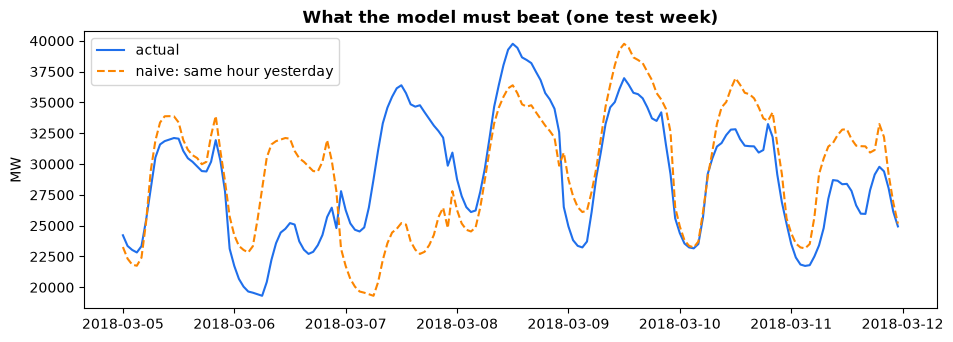

In [29]:
wk = test[(test["time"] >= "2018-03-05") & (test["time"] < "2018-03-12")]
fig, ax = plt.subplots()
ax.plot(wk["time"], wk[TARGET], color=BLUE, label="actual")
ax.plot(wk["time"], wk["load_lag_24"], color=ORANGE, ls="--", label="naive: same hour yesterday")
ax.set_title("What the model must beat (one test week)"); ax.set_ylabel("MW"); ax.legend()
fig.savefig(IMG / "partC" / "baseline_week.png", dpi=130, bbox_inches="tight"); plt.show()

1. The Provided forecast (reference) is by far the hardest baseline to beat, with a very low MAE of 269.80(MAPEof 0.93%).  Among naive baselines, "Naive: same hour yesterday" ($\text{MAE} = 2519.40\text{ MW}$) outperforms "Naive: same hour last week" ($\text{MAE} = 2642.76\text{ MW}$).
2. The daily naive baseline (load_lag_24) fails heavily during weekend transitions (Friday to Saturday and Sunday to Monday).  On Saturday, using Friday's high demand (a weekday) leads to a massive over-prediction.  On Monday, using Sunday's low demand (a weekend) causes a massive under-prediction.
3. The ML model must beat the daily naive error level of $\text{MAE} \approx 2519\text{ MW}$ ($\text{MAPE} \approx 8.72\%$) at minimum to prove machine learning adds value over simple persistence.  Ideally, it should strive to get as close as possible to the benchmark provided forecast ($\text{MAE} \approx 270\text{ MW}$).

## 10. Save the feature table

In [30]:
out = data[["time", TARGET, REFERENCE] + FEATURES]
out.to_csv(PROC / "trackA_features.csv", index=False)
print("saved:", PROC / "trackA_features.csv", "|", out.shape)

saved: C:\Users\Lim\PycharmProjects\alice-track-a-team-Lim\data\processed\trackA_features.csv | (34843, 22)
